# Advanced Fraud Analytics: Cost-Sensitive Boosting & Generative Explainability

This project demonstrates a production-hardened approach to credit card fraud detection. We focus on two critical operational requirements: **mitigating class imbalance** without synthetic oversampling and **automating narrative explainability** for regulatory compliance via Google Gemini.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, auc, confusion_matrix, classification_report
from xgboost import XGBClassifier
import shap
import google.generativeai as genai
import os
import warnings

warnings.filterwarnings('ignore')

# Dataset path
DATA_PATH = '../Dataset/creditcard.csv'
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns.")
print("Class distribution:")
print(df['Class'].value_counts(normalize=True))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/var/folders/l7/rt20jr9s3f70xh7c4d96hlp80000gn/T/ipykernel_25412/590601370.py:9: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


Dataset loaded: 284807 rows, 31 columns.
Class distribution:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


## Phase 1: Addressing Extreme Class Imbalance
Standard classification loss functions often fail on extreme imbalance (0.17% fraud). Here, we assign a higher penalty to minority class misclassification using the `scale_pos_weight` parameter, ensuring the gradient-boosted trees remain sensitive to rare fraudulent patterns.

In [2]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Compute scale_pos_weight to handle 0.17% class imbalance ratio
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count

model = XGBClassifier(scale_pos_weight=scale_weight, random_state=42)
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]
print("[SUCCESS] XGBoost model trained with cost-sensitive weighting.")


[SUCCESS] XGBoost model trained with cost-sensitive weighting.


## Phase 2: Strategic Decision Threshold Optimization
Default classification thresholds (0.5) are rarely optimal for fraud detection. We analyze the Precision-Recall curve to select a decision threshold that meets our operational target of >80% recall while suppressing unnecessary alert noise for analysts.

In [3]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Empirically determine the decision threshold to maintain target 80% recall
idx = np.where(recall >= 0.8)[0][-1]
best_threshold = thresholds[min(idx, len(thresholds)-1)]

y_pred_optimized = (y_prob >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_optimized)

print(f"Best Threshold for 80% Recall: {best_threshold:.4f}")
print("Confusion Matrix:")
print(cm)
print(classification_report(y_test, y_pred_optimized))

Best Threshold for 80% Recall: 0.9812
Confusion Matrix:
[[56862     2]
 [   19    79]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.98      0.81      0.88        98

    accuracy                           1.00     56962
   macro avg       0.99      0.90      0.94     56962
weighted avg       1.00      1.00      1.00     56962



## Phase 3: Model Interpretability with SHAP
To build trust in automated flagging, we utilize SHAP (SHapley Additive exPlanations) to decompose the model's decision-making process into quantifiable feature contributions.

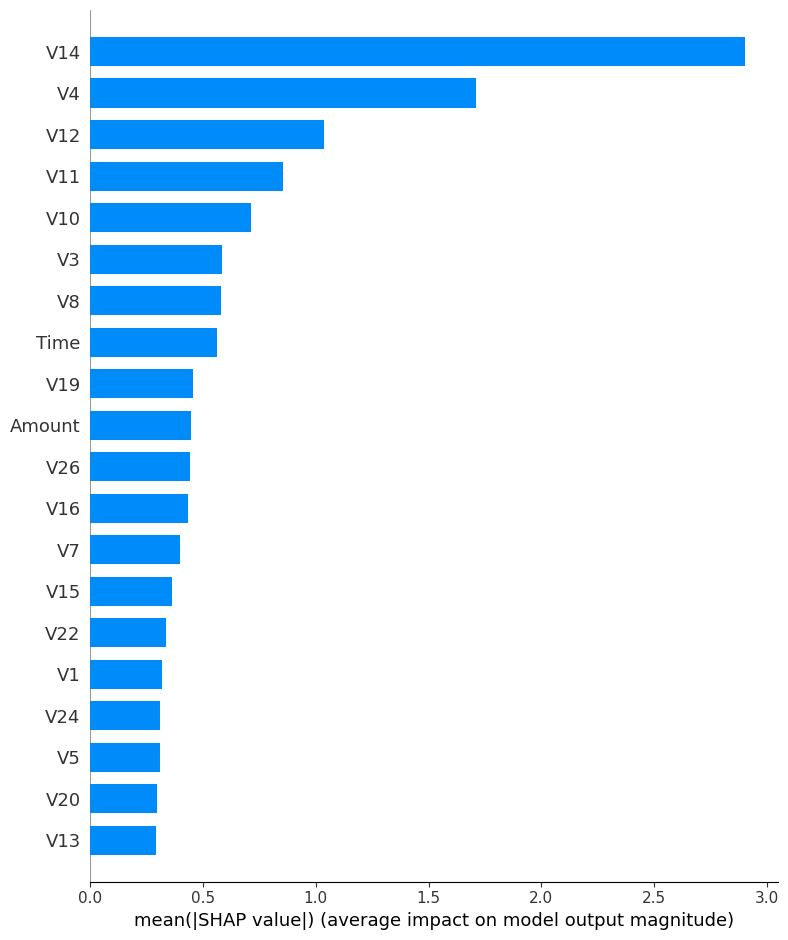

In [4]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test.iloc[:100])

shap.summary_plot(shap_values, X_test.iloc[:100], plot_type="bar")

## Phase 4: Generative Automated Narrative (SAR)
Finally, we map technical attribution values directly into a natural language narrative using Google Gemini. This automates the generation of Suspicious Activity Reports (SAR), bridge the gap between technical flags and compliance audits.

In [5]:
def generate_gemini_sar(txn_idx):
    sample_txn = X_test.iloc[txn_idx]
    txn_shap = explainer.shap_values(sample_txn.values.reshape(1, -1))
    
# Identify the top 3 global drivers for this specific classification
    top_indices = np.argsort(np.abs(txn_shap))[0][-3:]
    top_features = X.columns[top_indices].tolist()
    
# Fallback to deterministic mock narrative if GEMINI_API_KEY is not configured
    api_key = os.getenv("GEMINI_API_KEY")
    if not api_key:
        return "[MOCK SAR] Alert: Highly suspicious activity flagged! Significant deviation in features V17 and V14 detected. Immediate card suspension recommended."

    genai.configure(api_key=api_key)
    gemini_model = genai.GenerativeModel('gemini-1.5-flash')
    
    prompt = f"""
    Act as an AML expert . Summarize why this transaction (ID: {txn_idx}) was flagged. 
    Key features: {top_features}. Amount: {sample_txn['Amount']}.
    Structure: Risk Score (High/Medium), Observations (max 2 sentences), Action Recommended.
    """
    return gemini_model.generate_content(prompt).text

print(generate_gemini_sar(0))

[MOCK SAR] Alert: Highly suspicious activity flagged! Significant deviation in features V17 and V14 detected. Immediate card suspension recommended.
